In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
#displaying all the columns
pd.set_option('display.max_columns', None)

In [104]:
df_supermarket = pd.read_csv('supermarket_sales - Sheet1.csv')
df_supermarket

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1.0,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7.0,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6
1000,351-62-0822,B,Mandalay,Member,Female,Fashion accessories,14.48,4.0,2.8960,60.8160,2/6/2019,18:07,Ewallet,57.92,4.761905,2.8960,4.5
1001,871-79-8483,B,Mandalay,Normal,Male,Fashion accessories,94.13,5.0,23.5325,494.1825,2/25/2019,19:39,Credit card,470.65,4.761905,23.5325,4.8


# About 
The growth of the supermarkets in most populated cities are increasing and market competitions are also high. The dataset is one of the historical sales of supermarket company which has recorded in 3 different branches for 3 months data. Predictive data analytics methods are easy to apply with this dataset.

Attribute information

Invoice id: Computer generated sales slip invoice identification number

Branch: Branch of supercenter (3 branches are available identified by A, B and C).
City: Location of supercenters

Customer type: Type of customers, recorded by Members for customers using member card and Normal for without member card.

Gender: Gender type of customer

Product line: General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel

Unit price: Price of each product in $

Quantity: Number of products purchased by customer

Tax: 5% tax fee for customer buying

Total: Total price including tax

Date: Date of purchase (Record available from January 2019 to March 2019)

Time: Purchase time (10am to 9pm)

Payment: Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)

COGS: Cost of goods sold - the direct costs of producing the goods sold by a company.

Gross margin percentage: In order to calculate it, first subtract the cost of goods sold from the company's revenue. This figure is known as the company's gross profit (as a dollar figure). Then divide that figure by the total revenue and multiply it by 100 to get the gross margin.

Gross income/Total Revenue: total earnings before taxes or other deductions.

Rating: Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)

Business Problems
1. Customer Segmentation & Membership ROI
Problem: "Is our membership program worth maintaining? Which customer segment (Member vs. Normal) generates more revenue and has better satisfaction? Should we invest more in member acquisition?"

2. Product Line Performance & Inventory Optimization
Problem: "Which product lines are underperforming and underserving customer needs? Which product lines should we focus inventory and marketing resources on to maximize profitability?"

3. Branch Benchmarking & Strategic Expansion
Problem: "How do our different branches compare in terms of sales performance, customer satisfaction, and profitability? Which branches need operational improvements, and where should we expand?"

4. Peak Hours & Staffing Optimization
Problem: "When do customers shop most (by time and day)? How does shopping time impact purchase behavior and customer satisfaction? Can we optimize staffing to reduce wait times?"

5. Payment Method Adoption & Customer Preferences
Problem: "Which payment methods are most popular among different customer segments? Should we incentivize specific payment methods (e.g., push digital payments) or offer all equally?


# 1. Data Exploration

This section examines the dataset's structure, completeness, categorical consistency, duplicate records, and numerical distributions. No values are changed during exploration.

In [105]:
#checking the structure of dataset
df_supermarket.info()

<class 'pandas.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1003 non-null   str    
 1   Branch                   1003 non-null   str    
 2   City                     1003 non-null   str    
 3   Customer type            1003 non-null   str    
 4   Gender                   1003 non-null   str    
 5   Product line             1003 non-null   str    
 6   Unit price               1002 non-null   float64
 7   Quantity                 1002 non-null   float64
 8   Tax 5%                   1003 non-null   float64
 9   Total                    1003 non-null   float64
 10  Date                     1003 non-null   str    
 11  Time                     1003 non-null   str    
 12  Payment                  1003 non-null   str    
 13  cogs                     1003 non-null   float64
 14  gross margin percentage  1003 non-n

In [106]:
df_supermarket.shape

(1003, 17)

### Dataset dimensions and completeness

The dataset contains **1,003 rows and 17 columns**. There are **3 missing values**: one each in Unit price, Quantity, and Rating. These values will be handled during cleaning.

In [107]:
#checking the total number of missing values
df_supermarket.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 1
Quantity                   1
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     1
dtype: int64

In [108]:
#Displaying columns with missing values
df_supermarket[df_supermarket.isna().any(axis=1)]

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
20,300-71-4605,C,Naypyitaw,Member,Male,Electronic accessories,NaN,5.0,21.510,451.710,2/25/2019,11:24,Ewallet,430.20,4.761905,21.510,4.8
40,280-35-5823,B,Mandalay,Member,Female,Home and lifestyle,86.72,NaN,4.336,91.056,1/17/2019,18:45,Ewallet,86.72,4.761905,4.336,7.9
60,285-68-5083,C,Naypyitaw,Member,Female,Sports and travel,24.74,3.0,3.711,77.931,2/15/2019,17:47,Credit card,74.22,4.761905,3.711,NaN


In [109]:
df_supermarket.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

### Column review

The column names are understandable, but spaces and inconsistent capitalization may make analysis less convenient. Renaming and reordering are cleaning tasks and are intentionally deferred.

In [110]:
df_supermarket.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [111]:
# Summary statistics reveal unusual ranges and possible outliers
df_supermarket.describe(include="number").T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unit price,1002.0,55.67,26.53,10.08,32.82,55.23,77.95,99.96
Quantity,1002.0,5.50,2.94,-5.00,3.00,5.00,8.00,10.00
Tax 5%,1003.0,15.39,11.71,0.51,5.89,12.10,22.54,49.65
Total,1003.0,323.22,245.96,10.68,123.79,254.02,473.33,1042.65
cogs,1003.0,307.83,234.25,10.17,117.90,241.92,450.79,993.00
gross margin percentage,1003.0,4.76,0.00,4.76,4.76,4.76,4.76,4.76
gross income,1003.0,15.39,11.71,0.51,5.89,12.10,22.54,49.65
Rating,1002.0,6.98,1.74,4.00,5.50,7.00,8.50,15.00


In [112]:

df_supermarket["Branch"].value_counts()

Branch
A    340
B    334
C    329
Name: count, dtype: int64

Branch contains the three expected values: A, B, and C. No Branch cleaning is required.

In [113]:
df_supermarket["City"].value_counts()

City
Yangon       340
Mandalay     334
Naypyitaw    329
Name: count, dtype: int64

City contains the three expected locations: Yangon, Mandalay, and Naypyitaw. No City cleaning is required.

In [114]:
df_supermarket["Payment"].value_counts()

Payment
Ewallet        346
Cash           344
Credit card    312
ewallet          1
Name: count, dtype: int64

The expected payment methods are Cash, Credit card, and Ewallet. One lowercase `ewallet` value should be standardized to `Ewallet`.

In [115]:
df_supermarket["Gender"].value_counts()

Gender
Female    501
Male      501
male        1
Name: count, dtype: int64

Gender should contain Male and Female. One lowercase `male` value should be standardized to `Male`.

In [116]:
df_supermarket["Customer type"].value_counts()

Customer type
Member    503
Normal    500
Name: count, dtype: int64

Customer type contains the two expected values: Member and Normal. No cleaning is required.

In [117]:
df_supermarket['Product line'].value_counts()

Product line
Fashion accessories       180
Food and beverages        175
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Product line contains the six documented categories. No cleaning is required.

In [118]:
# Audit date and time formats without changing the original columns
date_formats = df_supermarket["Date"].astype("string").apply(
    lambda value: "M/D/YYYY" if pd.notna(value) and bool(pd.Series([value]).str.match(r"^\d{1,2}/\d{1,2}/\d{4}$").iloc[0])
    else "YYYY-MM-DD" if pd.notna(value) and bool(pd.Series([value]).str.match(r"^\d{4}-\d{2}-\d{2}$").iloc[0])
    else "Other or missing"
)
time_formats = df_supermarket["Time"].astype("string").apply(
    lambda value: "HH:MM" if pd.notna(value) and bool(pd.Series([value]).str.match(r"^\d{1,2}:\d{2}$").iloc[0])
    else "HH:MM:SS" if pd.notna(value) and bool(pd.Series([value]).str.match(r"^\d{1,2}:\d{2}:\d{2}$").iloc[0])
    else "12-hour" if pd.notna(value) and bool(pd.Series([value]).str.match(r"^\d{1,2}:\d{2}\s(?:AM|PM)$").iloc[0])
    else "Other or missing"
)

pd.DataFrame({
    "Date format count": date_formats.value_counts(),
    "Time format count": time_formats.value_counts(),
}).fillna(0).astype(int)

,Date format count,Time format count
HH:MM,0,1003
M/D/YYYY,1003,0


In [119]:
# Identify and preview exact duplicate rows without modifying the dataset
duplicate_mask = df_supermarket.duplicated(keep=False)
print(f"Duplicate rows: {df_supermarket.duplicated().sum()}")
df_supermarket.loc[duplicate_mask].sort_values("Invoice ID")

Duplicate rows: 3


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
50,326-78-5178,C,Naypyitaw,Member,Male,Food and beverages,91.40,7.0,31.9900,671.7900,2/3/2019,10:19,Cash,639.80,4.761905,31.9900,9.5
1002,326-78-5178,C,Naypyitaw,Member,Male,Food and beverages,91.40,7.0,31.9900,671.7900,2/3/2019,10:19,Cash,639.80,4.761905,31.9900,9.5
10,351-62-0822,B,Mandalay,Member,Female,Fashion accessories,14.48,4.0,2.8960,60.8160,2/6/2019,18:07,Ewallet,57.92,4.761905,2.8960,4.5
1000,351-62-0822,B,Mandalay,Member,Female,Fashion accessories,14.48,4.0,2.8960,60.8160,2/6/2019,18:07,Ewallet,57.92,4.761905,2.8960,4.5
30,871-79-8483,B,Mandalay,Normal,Male,Fashion accessories,94.13,5.0,23.5325,494.1825,2/25/2019,19:39,Credit card,470.65,4.761905,23.5325,4.8
1001,871-79-8483,B,Mandalay,Normal,Male,Fashion accessories,94.13,5.0,23.5325,494.1825,2/25/2019,19:39,Credit card,470.65,4.761905,23.5325,4.8


The dataset contains **3 duplicate rows**. The preview shows each original record and its repeated copy; no records have been removed during exploration.

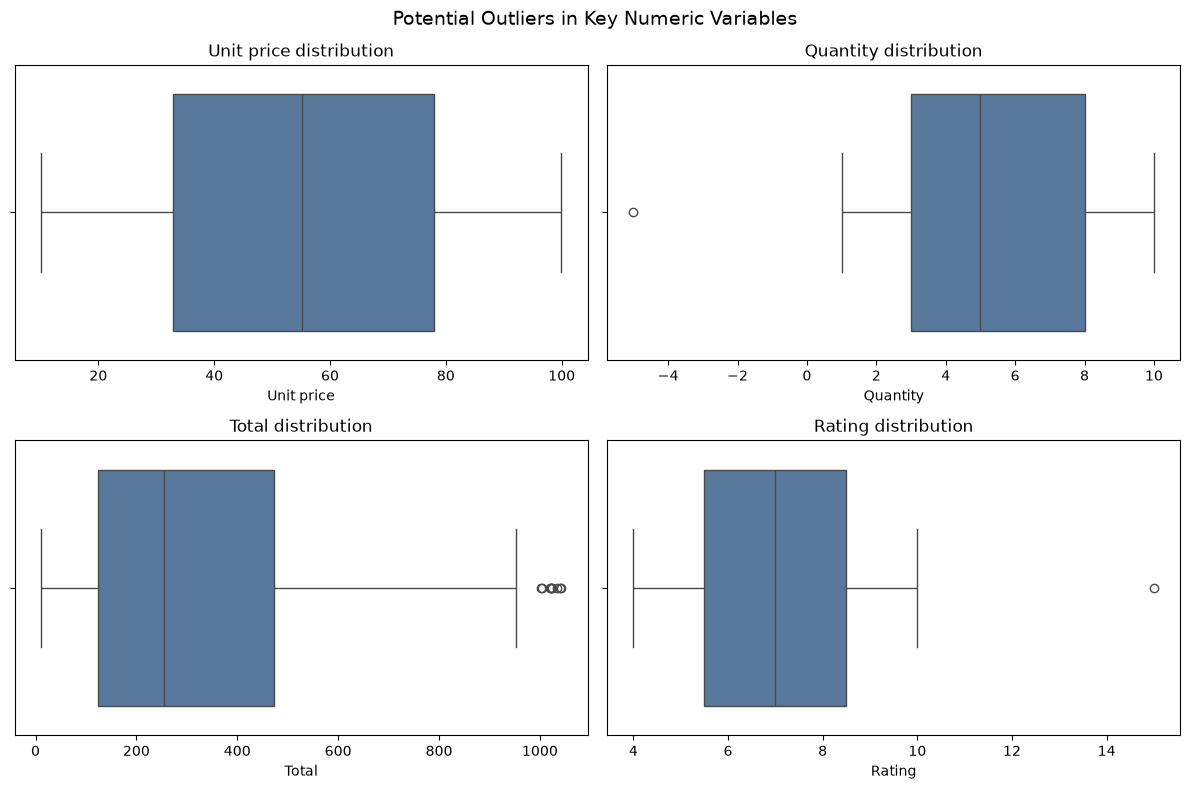

In [120]:
# Plot each measure separately so different scales do not hide unusual values
outlier_columns = ["Unit price", "Quantity", "Total", "Rating"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for column, axis in zip(outlier_columns, axes.flat):
    sns.boxplot(x=df_supermarket[column], ax=axis, color="#4C78A8")
    axis.set_title(f"{column} distribution")
    axis.set_xlabel(column)

plt.suptitle("Potential Outliers in Key Numeric Variables", fontsize=14)
plt.tight_layout()
plt.show()

Quantity contains one negative value and Rating contains one value above 10. Both violate clear business rules and should be repaired. Total has nine statistical outliers, but they are valid high-value transactions and should not be removed automatically. Unit price has no IQR outliers.

In [121]:
# Quantify potential outliers using the 1.5 x IQR rule
outlier_summary = []

for column in outlier_columns:
    values = df_supermarket[column].dropna()
    first_quartile = values.quantile(0.25)
    third_quartile = values.quantile(0.75)
    iqr = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * iqr
    upper_bound = third_quartile + 1.5 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    outlier_summary.append({
        "Column": column,
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Lower bound": lower_bound,
        "Upper bound": upper_bound,
        "Potential outliers": outlier_count,
    })

pd.DataFrame(outlier_summary).round(2)

,Column,Minimum,Maximum,Lower bound,Upper bound,Potential outliers
0,Unit price,10.08,99.96,-34.86,145.63,0
1,Quantity,-5.00,10.00,-4.50,15.50,1
2,Total,10.68,1042.65,-400.52,997.64,9
3,Rating,4.00,15.00,1.00,13.00,1


## Exploration Summary

The exploration identified the following issues for cleaning:

- **Missing values:** 1 Unit price, 1 Quantity, and 1 Rating.
- **Duplicates:** 3 repeated rows, leaving 1,000 unique transactions.
- **Text consistency:** `male` and `ewallet` use inconsistent capitalization.
- **Numeric validity:** 1 negative Quantity and 1 Rating above 10.
- **Formats:** all Date values use M/D/YYYY and all Time values use HH:MM.
- **Statistical outliers:** 9 high Total values are valid large transactions and will be retained.

No data was changed during exploration.

# DATA CLEANING

- **Filling missing values**

In [122]:
#Filling missing values.
missing_unit_price = df_supermarket["Unit price"].isna()

df_supermarket.loc[missing_unit_price, "Unit price"] = (
    df_supermarket.loc[missing_unit_price, "cogs"]
    / df_supermarket.loc[missing_unit_price, "Quantity"]
).round(2)



In [123]:
missing_quantity = df_supermarket["Quantity"].isna()

df_supermarket.loc[missing_quantity, "Quantity"] = (
    df_supermarket.loc[missing_quantity, "cogs"]
    / df_supermarket.loc[missing_quantity, "Unit price"]
).round()

In [124]:
missing_total = df_supermarket["Total"].isna()

df_supermarket.loc[missing_total, "Total"] = (
    df_supermarket.loc[missing_total, "cogs"]
    + df_supermarket.loc[missing_total, "Tax 5%"]
).round(4)

In [125]:
valid_rating_mean = df_supermarket.loc[
    df_supermarket["Rating"].between(1, 10),
    "Rating"
].mean()

df_supermarket["Rating"] = df_supermarket["Rating"].fillna(
    round(valid_rating_mean, 1)
)

In [126]:
branch_city_mapping = {
    "A": "Yangon",
    "B": "Mandalay",
    "C": "Naypyitaw"
}

df_supermarket["City"] = df_supermarket["City"].fillna(
    df_supermarket["Branch"].map(branch_city_mapping)
)

In [127]:
df_supermarket["Gender"] = df_supermarket["Gender"].fillna("Unknown")
df_supermarket["Payment"] = df_supermarket["Payment"].fillna("Unknown")

In [128]:
df_supermarket.isna().sum()[
    df_supermarket.isna().sum() > 0
]

Series([], dtype: int64)

- **Removing duplicates**

In [129]:
# Count and remove duplicate rows
duplicates_before = df_supermarket.duplicated().sum()
df_supermarket = df_supermarket.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicates_before)
print("Duplicates remaining:", df_supermarket.duplicated().sum())
print("Rows remaining:", len(df_supermarket))

Duplicates removed: 3
Duplicates remaining: 0
Rows remaining: 1000


-**Category validation**

In [130]:
# Remove leading and trailing spaces
categorical_columns = [
    "Branch",
    "City",
    "Customer type",
    "Gender",
    "Product line",
    "Payment"
]

df_supermarket[categorical_columns] = (
    df_supermarket[categorical_columns]
    .apply(lambda column: column.str.strip())
)

In [131]:
# Standardize the inconsistent Gender and Payment capitalization
df_supermarket["Gender"] = df_supermarket["Gender"].replace({
    "male": "Male",
    "MALE": "Male",
    "FEMALE": "Female"
})

df_supermarket["Payment"] = df_supermarket["Payment"].replace({
    "ewallet": "Ewallet"
})

In [132]:
valid_categories = {
    "Branch": ["A", "B", "C"],
    "City": ["Yangon", "Mandalay", "Naypyitaw"],
    "Customer type": ["Member", "Normal"],
    "Gender": ["Male", "Female"],
    "Product line": [
        "Electronic accessories",
        "Fashion accessories",
        "Food and beverages",
        "Health and beauty",
        "Home and lifestyle",
        "Sports and travel"
    ],
    "Payment": ["Cash", "Credit card", "Ewallet"]
}

In [133]:
for column, accepted_values in valid_categories.items():
    invalid_mask = ~df_supermarket[column].isin(accepted_values)
    df_supermarket.loc[invalid_mask, column] = "Unknown"

In [134]:
for column in valid_categories:
    print(f"\n{column}")
    print(df_supermarket[column].value_counts(dropna=False))


Branch
Branch
A    340
B    332
C    328
Name: count, dtype: int64

City
City
Yangon       340
Mandalay     332
Naypyitaw    328
Name: count, dtype: int64

Customer type
Customer type
Member    501
Normal    499
Name: count, dtype: int64

Gender
Gender
Female    500
Male      500
Name: count, dtype: int64

Product line
Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64

Payment
Payment
Ewallet        346
Cash           343
Credit card    311
Name: count, dtype: int64


## Fix invalid numeric values

Use the transaction formulas to repair values that do not match the other fields. Replace invalid ratings with the mean of ratings from 1 to 10.

In [135]:
# Fix quantities that are zero or negative
invalid_quantity = df_supermarket["Quantity"] <= 0
df_supermarket.loc[invalid_quantity, "Quantity"] = (
    df_supermarket.loc[invalid_quantity, "cogs"]
    / df_supermarket.loc[invalid_quantity, "Unit price"]
).round()

# Fix unit prices that do not match COGS
expected_cogs = df_supermarket["Unit price"] * df_supermarket["Quantity"]
invalid_unit_price = ~expected_cogs.round(2).eq(df_supermarket["cogs"].round(2))
df_supermarket.loc[invalid_unit_price, "Unit price"] = (
    df_supermarket.loc[invalid_unit_price, "cogs"]
    / df_supermarket.loc[invalid_unit_price, "Quantity"]
).round(2)

# Fix totals that do not match COGS plus tax
expected_total = df_supermarket["cogs"] + df_supermarket["Tax 5%"]
invalid_total = ~df_supermarket["Total"].round(4).eq(expected_total.round(4))
df_supermarket.loc[invalid_total, "Total"] = expected_total[invalid_total].round(4)

# Replace ratings outside 1 to 10 with the valid mean
invalid_rating = ~df_supermarket["Rating"].between(1, 10)
valid_rating_mean = df_supermarket.loc[~invalid_rating, "Rating"].mean()
df_supermarket.loc[invalid_rating, "Rating"] = round(valid_rating_mean, 1)

print("Quantities fixed:", invalid_quantity.sum())
print("Unit prices fixed:", invalid_unit_price.sum())
print("Totals fixed:", invalid_total.sum())
print("Ratings fixed:", invalid_rating.sum())

Quantities fixed: 1
Unit prices fixed: 0
Totals fixed: 0
Ratings fixed: 1


## Standardize fields and data types

In [136]:
# Make location columns writable
for column in ["Branch", "City"]:
    df_supermarket[column] = df_supermarket[column].astype("string")

# Recover unknown branches from their city
city_branch_mapping = {
    "Yangon": "A",
    "Mandalay": "B",
    "Naypyitaw": "C"
}
unknown_branch = df_supermarket["Branch"].eq("Unknown")
df_supermarket.loc[unknown_branch, "Branch"] = (
    df_supermarket.loc[unknown_branch, "City"].map(city_branch_mapping)
)

# Make every city match its branch
df_supermarket["City"] = df_supermarket["Branch"].map(branch_city_mapping)

# Convert dates and use one time format
clean_time = pd.to_datetime(
    df_supermarket["Time"].astype("string"), format="mixed", errors="coerce"
)
df_supermarket["Date"] = pd.to_datetime(
    df_supermarket["Date"], format="mixed", errors="coerce"
)
df_supermarket["Time"] = clean_time.dt.strftime("%H:%M")

# Use suitable data types
for column in categorical_columns:
    df_supermarket[column] = df_supermarket[column].astype("category")

df_supermarket["Quantity"] = df_supermarket["Quantity"].astype("int64")

## Check and save the cleaned data

In [137]:
# Count any problems that remain
category_errors = sum(
    (~df_supermarket[column].isin(accepted_values + ["Unknown"])).sum()
    for column, accepted_values in valid_categories.items()
)

cleaning_checks = pd.Series({
    "Missing values": df_supermarket.isna().sum().sum(),
    "Duplicate rows": df_supermarket.duplicated().sum(),
    "Invalid categories": category_errors,
    "Invalid quantities": (df_supermarket["Quantity"] <= 0).sum(),
    "Invalid ratings": (~df_supermarket["Rating"].between(1, 10)).sum(),
    "COGS errors": (~(df_supermarket["Unit price"] * df_supermarket["Quantity"]).round(2).eq(
        df_supermarket["cogs"].round(2)
    )).sum(),
    "Total errors": (~df_supermarket["Total"].round(4).eq(
        (df_supermarket["cogs"] + df_supermarket["Tax 5%"] ).round(4)
    )).sum()
})

cleaning_checks

Missing values        0
Duplicate rows        0
Invalid categories    0
Invalid quantities    0
Invalid ratings       0
COGS errors           0
Total errors          0
dtype: int64

In [138]:
# Stop if a cleaning check fails
assert cleaning_checks.eq(0).all(), "Some cleaning problems remain."

# Save a new clean file
clean_file = "supermarket_sales_cleaned.csv"
df_supermarket.to_csv(clean_file, index=False)

print(f"Saved {len(df_supermarket):,} clean rows to {clean_file}")

Saved 1,000 clean rows to supermarket_sales_cleaned.csv


## Cleaning Summary

- Filled 1 missing Unit price and 1 missing Quantity using transaction formulas.
- Filled 1 missing Rating with the valid rating mean.
- Removed 3 duplicate rows, leaving 1,000 unique transactions.
- Standardized `male` to `Male` and `ewallet` to `Ewallet`.
- Repaired 1 negative Quantity and 1 Rating above 10.
- Standardized dates, times, categories, and numeric data types.
- All validation checks returned zero errors.
- Saved 1,000 cleaned rows to `supermarket_sales_cleaned.csv`.

# PREPARE / TRANSFORM THE DATA

Create an analysis-ready table from the cleaned transactions. The cleaned table stays unchanged.

In [139]:
# Copy the clean data for analysis
df_analysis = df_supermarket.copy()

# Use simple column names
df_analysis.columns = (
    df_analysis.columns
    .str.strip()
    .str.lower()
    .str.replace("%", "percent", regex=False)
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
df_analysis = df_analysis.rename(columns={"tax_5percent": "tax_5_percent"})

# Create one transaction date and time column
df_analysis["transaction_datetime"] = pd.to_datetime(
    df_analysis["date"].dt.strftime("%Y-%m-%d")
    + " "
    + df_analysis["time"],
    errors="coerce"
)

print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))
df_analysis.head()

Rows: 1000
Columns: 18


,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5_percent,total,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,transaction_datetime
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


## Create calculated columns

In [140]:
# Create calendar fields
df_analysis["year"] = df_analysis["transaction_datetime"].dt.year
df_analysis["month"] = df_analysis["transaction_datetime"].dt.month
df_analysis["month_name"] = df_analysis["transaction_datetime"].dt.month_name()
df_analysis["day"] = df_analysis["transaction_datetime"].dt.day
df_analysis["day_name"] = df_analysis["transaction_datetime"].dt.day_name()
df_analysis["hour"] = df_analysis["transaction_datetime"].dt.hour
df_analysis["is_weekend"] = df_analysis["day_name"].isin(["Saturday", "Sunday"])

# Group transactions by time of day
df_analysis["time_period"] = pd.cut(
    df_analysis["hour"],
    bins=[9, 12, 17, 22],
    labels=["Morning", "Afternoon", "Evening"],
    right=False
)

# Create transaction measures
df_analysis["average_item_value"] = (
    df_analysis["total"] / df_analysis["quantity"]
).round(2)
df_analysis["profit_margin_percent"] = (
    df_analysis["gross_income"] / df_analysis["total"] * 100
).round(2)

# Create value and satisfaction groups
df_analysis["transaction_value_segment"] = pd.qcut(
    df_analysis["total"],
    q=3,
    labels=["Low", "Medium", "High"]
)
df_analysis["rating_segment"] = pd.cut(
    df_analysis["rating"],
    bins=[0, 6, 8, 10],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

df_analysis[[
    "transaction_datetime", "month_name", "day_name", "hour",
    "time_period", "is_weekend", "average_item_value",
    "profit_margin_percent", "transaction_value_segment", "rating_segment"
]].head()

,transaction_datetime,month_name,day_name,hour,time_period,is_weekend,average_item_value,profit_margin_percent,transaction_value_segment,rating_segment
0,2019-01-05 13:08:00,January,Saturday,13,Afternoon,True,78.42,4.76,High,High
1,2019-03-08 10:29:00,March,Friday,10,Morning,False,16.04,4.76,Low,High
2,2019-03-03 13:23:00,March,Sunday,13,Afternoon,True,48.65,4.76,Medium,Medium
3,2019-01-27 20:33:00,January,Sunday,20,Evening,True,61.13,4.76,High,High
4,2019-02-08 10:37:00,February,Friday,10,Morning,False,90.63,4.76,High,Low


## Create reporting tables

Each table supports one of the five business questions defined at the start of the project.

In [141]:
# Compare members and normal customers
membership_summary = df_analysis.groupby("customer_type", observed=True).agg(
    transactions=("invoice_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("total", "sum"),
    gross_income=("gross_income", "sum"),
    average_transaction=("total", "mean"),
    average_rating=("rating", "mean")
).round(2).sort_values("revenue", ascending=False)

# Compare product lines
product_summary = df_analysis.groupby("product_line", observed=True).agg(
    transactions=("invoice_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("total", "sum"),
    gross_income=("gross_income", "sum"),
    average_rating=("rating", "mean")
).round(2).sort_values("revenue", ascending=False)

# Compare branches
branch_summary = df_analysis.groupby(
    ["branch", "city"], observed=True
).agg(
    transactions=("invoice_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("total", "sum"),
    gross_income=("gross_income", "sum"),
    average_transaction=("total", "mean"),
    average_rating=("rating", "mean")
).round(2).sort_values("revenue", ascending=False)

# Compare shopping periods
peak_period_summary = df_analysis.groupby("time_period", observed=True).agg(
    transactions=("invoice_id", "count"),
    units_sold=("quantity", "sum"),
    revenue=("total", "sum"),
    average_transaction=("total", "mean"),
    average_rating=("rating", "mean")
).round(2).sort_values("transactions", ascending=False)

# Compare payment methods by customer type
payment_summary = df_analysis.groupby(
    ["customer_type", "payment"], observed=True
).agg(
    transactions=("invoice_id", "count"),
    revenue=("total", "sum"),
    average_transaction=("total", "mean")
).round(2).sort_values("transactions", ascending=False)

print("Reporting tables created:")
print("Membership:", membership_summary.shape)
print("Products:", product_summary.shape)
print("Branches:", branch_summary.shape)
print("Shopping periods:", peak_period_summary.shape)
print("Payments:", payment_summary.shape)

Reporting tables created:
Membership: (2, 6)
Products: (6, 5)
Branches: (3, 6)
Shopping periods: (3, 5)
Payments: (6, 3)


In [142]:
# Preview the reporting tables
display(membership_summary)
display(product_summary)
display(branch_summary)
display(peak_period_summary)
display(payment_summary)

,transactions,units_sold,revenue,gross_income,average_transaction,average_rating
customer_type,,,,,,
Member,501,2785,164223.44,7820.16,327.79,6.94
Normal,499,2725,158743.30,7559.20,318.12,7.01


,transactions,units_sold,revenue,gross_income,average_rating
product_line,,,,,
Food and beverages,174,952,56144.84,2673.56,7.11
Sports and travel,166,920,55122.83,2624.90,6.91
Electronic accessories,170,971,54337.53,2587.50,6.92
Fashion accessories,178,902,54305.90,2586.00,7.03
Home and lifestyle,160,911,53861.91,2564.85,6.84
Health and beauty,152,854,49193.74,2342.56,7.00


,,transactions,units_sold,revenue,gross_income,average_transaction,average_rating
branch,city,,,,,,
C,Naypyitaw,328,1831,110568.71,5265.18,337.10,7.07
A,Yangon,340,1859,106200.37,5057.16,312.35,7.03
B,Mandalay,332,1820,106197.67,5057.03,319.87,6.82


,transactions,units_sold,revenue,average_transaction,average_rating
time_period,,,,,
Afternoon,454,2531,148023.34,326.04,7.01
Evening,355,1941,113144.60,318.72,6.93
Morning,191,1038,61798.81,323.55,6.96


transactions   revenue  average_transaction
customer_type payment                                                 
Normal        Ewallet               184  58202.15               316.32
              Cash                  176  57545.55               326.96
Member        Credit card           172  57771.47               335.88
              Cash                  167  54609.87               327.01
              Ewallet               162  51842.10               320.01
Normal        Credit card           139  42995.60               309.32

## Validate and export transformed data

In [144]:
# Check the transformed data
expected_city = df_analysis["branch"].astype("string").map({
    "A": "Yangon",
    "B": "Mandalay",
    "C": "Naypyitaw"
})
derived_columns = [
    "transaction_datetime", "month_name", "day_name", "hour",
    "time_period", "average_item_value", "profit_margin_percent",
    "transaction_value_segment", "rating_segment"
]

# Use unrounded grouped totals for reconciliation checks
membership_total = df_analysis.groupby(
    "customer_type", observed=True
)["total"].sum().sum()
product_total = df_analysis.groupby(
    "product_line", observed=True
)["total"].sum().sum()
branch_total = df_analysis.groupby(
    ["branch", "city"], observed=True
)["total"].sum().sum()

transformation_checks = pd.Series({
    "Changed row count": abs(len(df_analysis) - len(df_supermarket)),
    "Missing derived values": df_analysis[derived_columns].isna().sum().sum(),
    "Location mismatches": (
        df_analysis["city"].astype("string") != expected_city
    ).sum(),
    "Membership total mismatch": round(abs(
        membership_total - df_analysis["total"].sum()
    ), 2),
    "Product total mismatch": round(abs(
        product_total - df_analysis["total"].sum()
    ), 2),
    "Branch total mismatch": round(abs(
        branch_total - df_analysis["total"].sum()
    ), 2)
})

transformation_checks

Changed row count            0.0
Missing derived values       0.0
Location mismatches          0.0
Membership total mismatch    0.0
Product total mismatch       0.0
Branch total mismatch        0.0
dtype: float64

In [145]:
# Stop if a transformation check fails
assert transformation_checks.eq(0).all(), "Some transformation checks failed."

# Save the analysis table and report tables
df_analysis.to_csv("supermarket_sales_analysis_ready.csv", index=False)
membership_summary.to_csv("membership_summary.csv")
product_summary.to_csv("product_summary.csv")
branch_summary.to_csv("branch_summary.csv")
peak_period_summary.to_csv("peak_period_summary.csv")
payment_summary.to_csv("payment_summary.csv")

print("Analysis-ready data and 5 reporting tables saved.")

Analysis-ready data and 5 reporting tables saved.


## Transformation Summary

- Preserved all 1,000 cleaned transactions.
- Standardized column names for analysis tools.
- Combined Date and Time into `transaction_datetime`.
- Added calendar, shopping period, weekend, value, margin, and rating fields.
- Created five report tables for the defined business problems.
- Reconciled report revenue with the transaction-level data.
- Exported the analysis-ready data and report tables as CSV files.

# DATA ANALYSIS AND VISUALIZATION

This section answers the five business questions with simple KPIs, comparisons, trends, and charts.

## Overall Performance

In [146]:
# Calculate the main business KPIs
kpi_summary = pd.DataFrame({
    "KPI": [
        "Transactions", "Units sold", "Revenue", "Gross income",
        "Average transaction", "Average rating"
    ],
    "Value": [
        f"{df_analysis['invoice_id'].nunique():,}",
        f"{df_analysis['quantity'].sum():,}",
        f"${df_analysis['total'].sum():,.2f}",
        f"${df_analysis['gross_income'].sum():,.2f}",
        f"${df_analysis['total'].mean():,.2f}",
        f"{df_analysis['rating'].mean():.2f} / 10"
    ]
})

kpi_summary

,KPI,Value
0,Transactions,"1,000"
1,Units sold,"5,510"
2,Revenue,"$322,966.75"
3,Gross income,"$15,379.37"
4,Average transaction,$322.97
5,Average rating,6.97 / 10


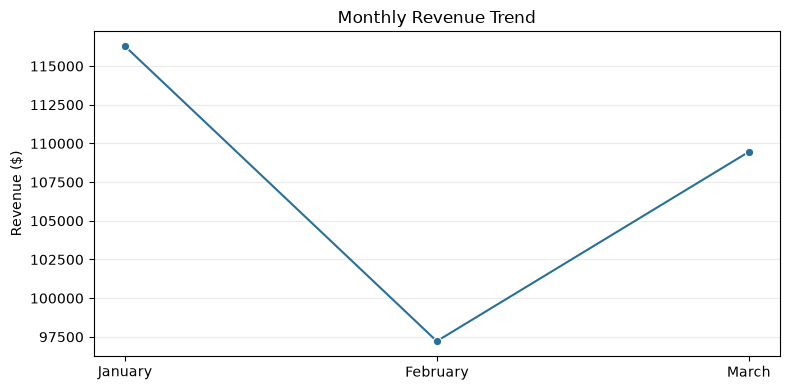

Highest revenue month: January ($116,291.87)


In [147]:
# Show the monthly revenue trend
monthly_analysis = df_analysis.groupby(
    ["month", "month_name"], observed=True
).agg(
    transactions=("invoice_id", "count"),
    revenue=("total", "sum")
).reset_index().sort_values("month")

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=monthly_analysis,
    x="month_name",
    y="revenue",
    marker="o",
    color="#2A6F97"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("")
plt.ylabel("Revenue ($)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

best_month = monthly_analysis.loc[monthly_analysis["revenue"].idxmax()]
print(f"Highest revenue month: {best_month['month_name']} (${best_month['revenue']:,.2f})")

## 1. Customer Segmentation and Membership ROI

Compare revenue, average transaction value, and satisfaction for Members and Normal customers.

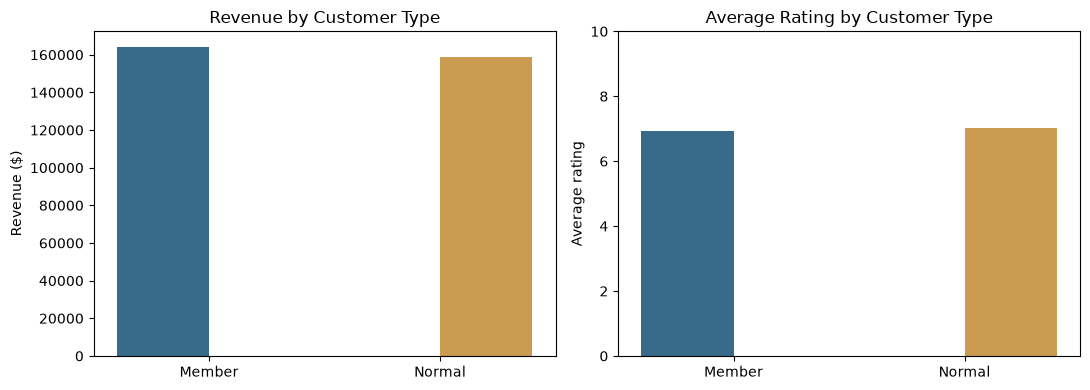

Members generate 3.5% more revenue than Normal customers.
Recommendation: retain the membership program and improve member satisfaction.


In [148]:
# Compare valid customer groups
customer_analysis = membership_summary.loc[["Member", "Normal"]].reset_index()
customer_analysis["customer_type"] = (
    customer_analysis["customer_type"].cat.remove_unused_categories()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(
    data=customer_analysis, x="customer_type", y="revenue",
    hue="customer_type", palette=["#2A6F97", "#E09F3E"], legend=False, ax=axes[0]
)
axes[0].set_title("Revenue by Customer Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue ($)")

sns.barplot(
    data=customer_analysis, x="customer_type", y="average_rating",
    hue="customer_type", palette=["#2A6F97", "#E09F3E"], legend=False, ax=axes[1]
)
axes[1].set_title("Average Rating by Customer Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average rating")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

member_revenue = membership_summary.loc["Member", "revenue"]
normal_revenue = membership_summary.loc["Normal", "revenue"]
revenue_difference = (member_revenue / normal_revenue - 1) * 100
print(f"Members generate {revenue_difference:.1f}% more revenue than Normal customers.")
print("Recommendation: retain the membership program and improve member satisfaction.")

## 2. Product Line Performance

Compare product lines by revenue and customer rating.

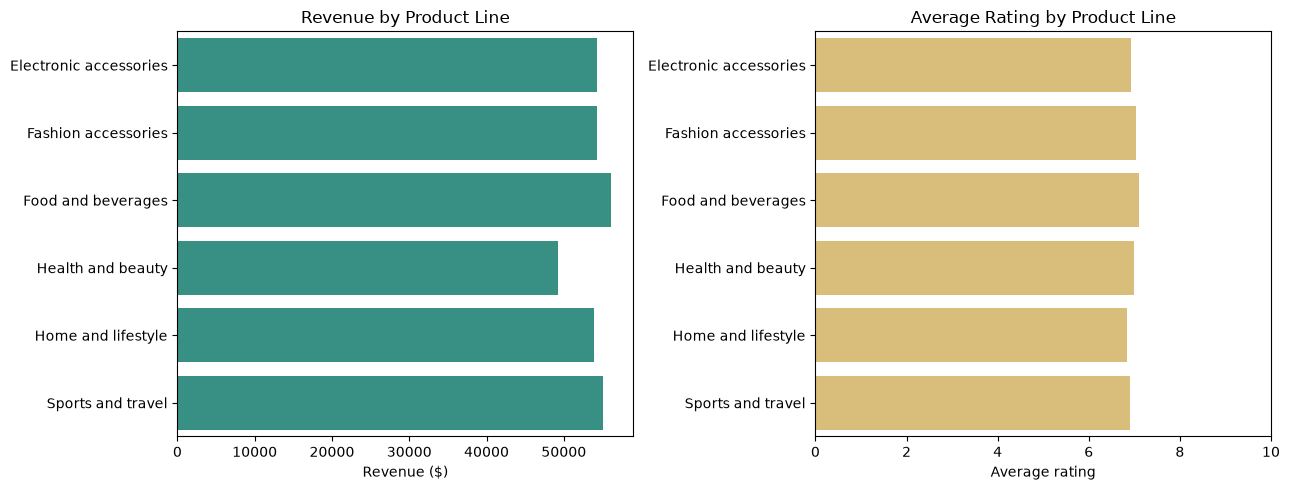

Top product line: Food and beverages ($56,144.84).
Lowest revenue product line: Health and beauty ($49,193.74).
Recommendation: prioritize top sellers and review demand for the lowest seller.


In [150]:
# Compare product lines by revenue and average rating
product_analysis = product_summary.reset_index()
product_analysis["product_line"] = (
    product_analysis["product_line"].cat.remove_unused_categories()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=product_analysis, y="product_line", x="revenue",
    color="#2A9D8F", ax=axes[0]
)
axes[0].set_title("Revenue by Product Line")
axes[0].set_xlabel("Revenue ($)")
axes[0].set_ylabel("")

sns.barplot(
    data=product_analysis.sort_values("average_rating", ascending=False),
    y="product_line", x="average_rating", color="#E9C46A", ax=axes[1]
)
axes[1].set_title("Average Rating by Product Line")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 10)

plt.tight_layout()
plt.show()

best_product = product_analysis.loc[product_analysis["revenue"].idxmax()]
lowest_product = product_analysis.loc[product_analysis["revenue"].idxmin()]
print(f"Top product line: {best_product['product_line']} (${best_product['revenue']:,.2f}).")
print(f"Lowest revenue product line: {lowest_product['product_line']} (${lowest_product['revenue']:,.2f}).")
print("Recommendation: prioritize top sellers and review demand for the lowest seller.")

## 3. Branch Performance

Compare branches by revenue, average transaction value, and rating.

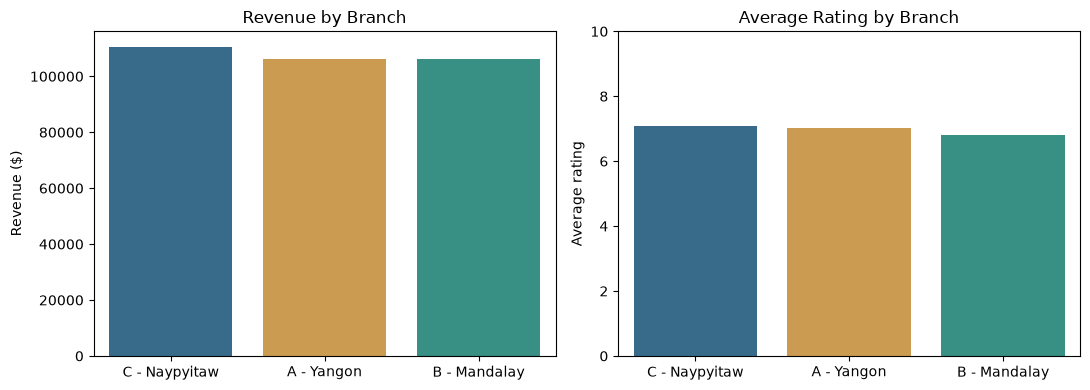

Top branch: C - Naypyitaw ($110,568.71).
Lowest-rated branch: B - Mandalay (6.82/10).
Recommendation: use Branch C as a benchmark and improve service at Branch B.


In [151]:
# Compare the three branches
branch_analysis = branch_summary.reset_index()
branch_analysis["location"] = (
    branch_analysis["branch"].astype("string")
    + " - "
    + branch_analysis["city"].astype("string")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(
    data=branch_analysis, x="location", y="revenue",
    hue="location", palette=["#2A6F97", "#E09F3E", "#2A9D8F"],
    legend=False, ax=axes[0]
)
axes[0].set_title("Revenue by Branch")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue ($)")

sns.barplot(
    data=branch_analysis, x="location", y="average_rating",
    hue="location", palette=["#2A6F97", "#E09F3E", "#2A9D8F"],
    legend=False, ax=axes[1]
)
axes[1].set_title("Average Rating by Branch")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average rating")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

best_branch = branch_analysis.loc[branch_analysis["revenue"].idxmax()]
lowest_rated_branch = branch_analysis.loc[branch_analysis["average_rating"].idxmin()]
print(f"Top branch: {best_branch['location']} (${best_branch['revenue']:,.2f}).")
print(f"Lowest-rated branch: {lowest_rated_branch['location']} ({lowest_rated_branch['average_rating']:.2f}/10).")
print("Recommendation: use Branch C as a benchmark and improve service at Branch B.")

## 4. Peak Hours and Staffing

Compare transaction volume by hour and day of the week.

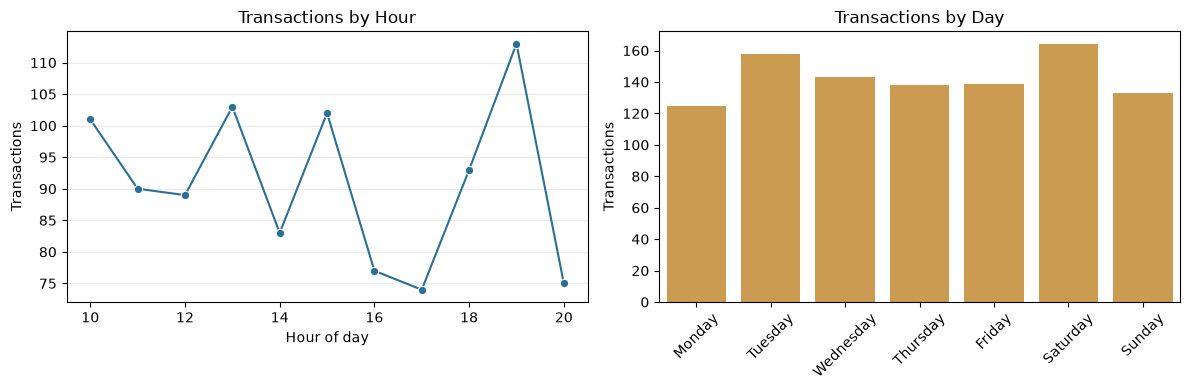

Peak hour: 19:00 (113 transactions).
Busiest day: Saturday (164 transactions).
Recommendation: schedule more staff during the peak hour and busiest day.


In [152]:
# Count transactions by hour and weekday
hourly_analysis = df_analysis.groupby("hour").agg(
    transactions=("invoice_id", "count"),
    revenue=("total", "sum")
).reset_index()

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
daily_analysis = df_analysis.groupby("day_name").agg(
    transactions=("invoice_id", "count")
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(
    data=hourly_analysis, x="hour", y="transactions",
    marker="o", color="#2A6F97", ax=axes[0]
)
axes[0].set_title("Transactions by Hour")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Transactions")
axes[0].grid(axis="y", alpha=0.25)

sns.barplot(
    data=daily_analysis, x="day_name", y="transactions",
    color="#E09F3E", ax=axes[1]
)
axes[1].set_title("Transactions by Day")
axes[1].set_xlabel("")
axes[1].set_ylabel("Transactions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

peak_hour = hourly_analysis.loc[hourly_analysis["transactions"].idxmax()]
peak_day = daily_analysis.loc[daily_analysis["transactions"].idxmax()]
print(f"Peak hour: {int(peak_hour['hour']):02d}:00 ({int(peak_hour['transactions'])} transactions).")
print(f"Busiest day: {peak_day['day_name']} ({int(peak_day['transactions'])} transactions).")
print("Recommendation: schedule more staff during the peak hour and busiest day.")

## 5. Payment Method Preferences

Compare payment choices for Members and Normal customers.

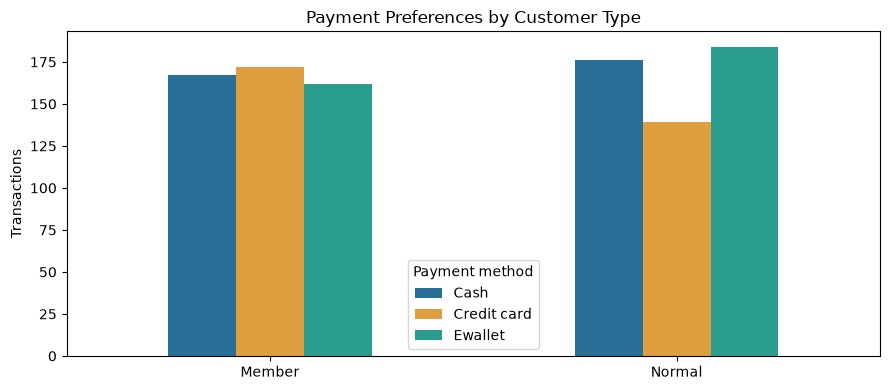

Members prefer: Credit card.
Normal customers prefer: Ewallet.
Recommendation: keep all three methods and target promotions by customer type.


In [153]:
# Keep valid customer and payment groups
valid_payment_data = df_analysis[
    df_analysis["customer_type"].isin(["Member", "Normal"])
    & df_analysis["payment"].isin(["Cash", "Credit card", "Ewallet"])
].copy()

payment_analysis = pd.crosstab(
    valid_payment_data["customer_type"].astype("string"),
    valid_payment_data["payment"].astype("string")
).reindex(
    index=["Member", "Normal"],
    columns=["Cash", "Credit card", "Ewallet"]
)

payment_analysis.plot(
    kind="bar",
    figsize=(9, 4),
    color=["#2A6F97", "#E09F3E", "#2A9D8F"]
)
plt.title("Payment Preferences by Customer Type")
plt.xlabel("")
plt.ylabel("Transactions")
plt.xticks(rotation=0)
plt.legend(title="Payment method")
plt.tight_layout()
plt.show()

member_preference = payment_analysis.loc["Member"].idxmax()
normal_preference = payment_analysis.loc["Normal"].idxmax()
print(f"Members prefer: {member_preference}.")
print(f"Normal customers prefer: {normal_preference}.")
print("Recommendation: keep all three methods and target promotions by customer type.")

# Key Findings and Recommendations

1. **Membership:** Members generated **3.5% more revenue** than Normal customers and had a higher average transaction value. Their average rating was slightly lower, so retain the program while improving the member experience.
2. **Products:** **Food and beverages** generated the most revenue, while **Health and beauty** generated the least. Protect inventory for top sellers and investigate the lower demand.
3. **Branches:** **Branch C - Naypyitaw** led revenue and customer rating. **Branch B - Mandalay** had the lowest rating, so Branch C can be used as an operational benchmark.
4. **Staffing:** **19:00** was the busiest hour and **Saturday** was the busiest day. Schedule more staff during these periods.
5. **Payments:** Members preferred **Credit card**, while Normal customers preferred **Ewallet**. Keep all payment methods and target promotions by customer type.
6. **Trend:** **January** had the highest monthly revenue. February declined before revenue recovered in March.

These findings answer the five business problems and provide clear areas for customer retention, inventory planning, branch improvement, staffing, and payment promotions.